# Fine-Tune YOLOv8n Detector on Real Sentinel-1 (Phase I -> Phase II)

**Context:** Zero-shot domain transfer from iVision-MRSSD (simulated) to real
Sentinel-1 GRD failed (mAP@0.5 = 0.0, confirmed via 9 independent checks).
This notebook fine-tunes the Phase I detector on **real AIS vessel annotations**
(Global Fishing Watch, 3,321+ boxes across multiple scenes).

**Key design decisions:**
- Starting from original `.pt` PyTorch weights (NOT ONNX -- quantization is
  strictly a post-training step)
- Full fine-tuning (freeze=0) -- all layers trainable (diagnosed mAP=0 was due to fixed 8×10px bboxes, not frozen layers)
- Input size 640x640 (model native, not tile size)
- Checkpoints saved to Google Drive during training
- ONNX FP32 + INT8 export only after fine-tuning is complete

---

## Cell 1 -- Setup

Install dependencies, mount Google Drive, locate:
- The **Phase I `.pt` weights** (must be FP32, pre-ONNX/INT8)
- The **fine-tuning dataset** (built via `build_finetune_dataset.py`)

In [1]:
# Install ultralytics and dependencies
!pip install -q ultralytics matplotlib pillow numpy tqdm

import ultralytics
import os, sys, json, shutil
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from ultralytics import YOLO

print(f"Ultralytics: {ultralytics.__version__}")
print(f"Python:      {sys.version}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.102
Python:      3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

print("\n=== Phase I weights (.pt) ===")
print("Upload the FP32 .pt file from phase_post0/models/ to your Drive.")
print("Recommended: yolov8n_mrssd_v1_18mb_fp32.pt (18 MB, original FP32)")
print("  Or: yolov8n_mrssd_v1_6mb.pt (6 MB, may be INT8)")
print()

# --- CONFIGURE THESE PATHS ---
# Path to the Phase I .pt weights (FP32, NOT ONNX)
PT_PATH = "/content/drive/MyDrive/maritime_sar_processing/models/yolov8n_mrssd_v1_18mb_fp32.pt"

# Path to the fine-tuning dataset (uploaded as ZIP or folder)
DATASET_ZIP = "/content/drive/MyDrive/maritime_sar_processing/dataset_finetune.zip"
DATASET_DIR = "/content/dataset_finetune"
# ----------------------------./phase0/notebooks/colab_finetune_yolo.ipynb

# Verify .pt file existence
if not os.path.exists(PT_PATH):
    print(f"PT weights NOT FOUND at: {PT_PATH}")
    print("Please upload a .pt file to Drive and update PT_PATH above.")
    print("Available files in the project: phase_post0/models/")
    print("  - yolov8n_mrssd_v1_18mb_fp32.pt (18 MB -- prefer this one)")
    print("  - yolov8n_mrssd_v1_6mb.pt (6 MB, may be INT8-quantized)")
else:
    pt_size = os.path.getsize(PT_PATH) / (1024 * 1024)
    print(f"PT weights found: {PT_PATH} ({pt_size:.0f} MB)")
    if pt_size < 10:
        print("   File is < 10 MB -- may be INT8-quantized.")
        print("   Fine-tuning from INT8 weights is possible but NOT recommended.")
        print("   The 18 MB FP32 version is preferred for fine-tuning.")

# Verify / extract dataset
if os.path.isdir(DATASET_DIR):
    print(f"Dataset directory found: {DATASET_DIR}")
elif os.path.exists(DATASET_ZIP):
    print(f"Extracting dataset from {DATASET_ZIP}...")
    import zipfile
    os.makedirs(DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zf:
        zf.extractall(DATASET_DIR)
    print(f"Dataset extracted to {DATASET_DIR}")
else:
    print(f"Neither {DATASET_DIR} nor {DATASET_ZIP} found.")
    print("Upload the ZIP built by build_finetune_dataset.py --zip to Drive.")

# Find data.yaml
yaml_path = None
for f in Path(DATASET_DIR).rglob("*.yaml"):
    if 'data' in f.name.lower() or 'dataset' in f.name.lower():
        yaml_path = f
        break
if yaml_path is None:
    print("data.yaml not found in extracted dataset.")
else:
    print(f"data.yaml found: {yaml_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Phase I weights (.pt) ===
Upload the FP32 .pt file from phase_post0/models/ to your Drive.
Recommended: yolov8n_mrssd_v1_18mb_fp32.pt (18 MB, original FP32)
  Or: yolov8n_mrssd_v1_6mb.pt (6 MB, may be INT8)

PT weights found: /content/drive/MyDrive/maritime_sar_processing/models/yolov8n_mrssd_v1_18mb_fp32.pt (18 MB)
Dataset directory found: /content/dataset_finetune
data.yaml found: /content/dataset_finetune/dataset_finetune/data.yaml


## Cell 2 -- Dataset Verification

Before any training: verify dataset integrity visually and numerically.

In [ ]:
# Traceability: dataset composition per split (inline, no external deps)\nimport json, os, sys, glob\n\ndef analyze_dataset_local():\n    # Find dataset_summary.json\n    for candidate in glob.glob("/content/**/dataset_summary.json", recursive=True):\n        summary_path = candidate\n        break\n    else:\n        print("dataset_summary.json not found")\n        return\n    \n    with open(summary_path) as f:\n        data = json.load(f)\n    \n    print("=" * 65)\n    print("  DATASET TRACEABILITY")\n    print("=" * 65)\n    print(f"  Total images: {data[\"total_images\"]}")\n    print(f"  Total boxes:  {data[\"total_boxes\"]}")\n    print()\n    \n    print('--- Scenes included ---')\n    for s in data["scenes"]:\n        sat = "S1C" if "S1C" in s["id"] else ("S1D" if "S1D" in s["id"] else "???")\n        print(f"  [{sat}] {s[\"short_id\"]}: {s[\"labels\"]} labels, {s[\"boxes\"]} boxes")\n    print()\n    \n    print('--- Per-split platform composition ---')\n    base_dir = os.path.dirname(summary_path)\n    for split in ["train", "val", "test"]:\n        split_dir = os.path.join(base_dir, "labels", split)\n        if not os.path.isdir(split_dir):\n            continue\n        \n        s1c = sum(1 for f in os.listdir(split_dir) if f.startswith("S1C") and f.endswith(".txt"))\n        s1d = sum(1 for f in os.listdir(split_dir) if f.startswith("S1D") and f.endswith(".txt"))\n        total = s1c + s1d\n        pct_s1c = 100 * s1c / total if total > 0 else 0\n        pct_s1d = 100 * s1d / total if total > 0 else 0\n        alert = "⚠️ DOMINATED!" if pct_s1c > 80 or pct_s1d > 80 else ""\n        print(f"  {split}: {s1c} S1C ({pct_s1c:.0f}%) / {s1d} S1D ({pct_s1d:.0f}%) / {total} total {alert}")\n    print()\n    \n    print('--- Split counts ---')\n    for split, count in data["split"].items():\n        print(f"  {split}: {count} images")\n    print("=" * 65)\n    \nanalyze_dataset_local()\n

  DATASET VERIFICATION & PATH FIX
Updated 'path' in data.yaml to: /content/dataset_finetune/dataset_finetune

--- Split counts ---
  train: 3649 images, 3649 labels OK
  val: 10 images, 10 labels OK
  test: 2820 images, 2820 labels OK


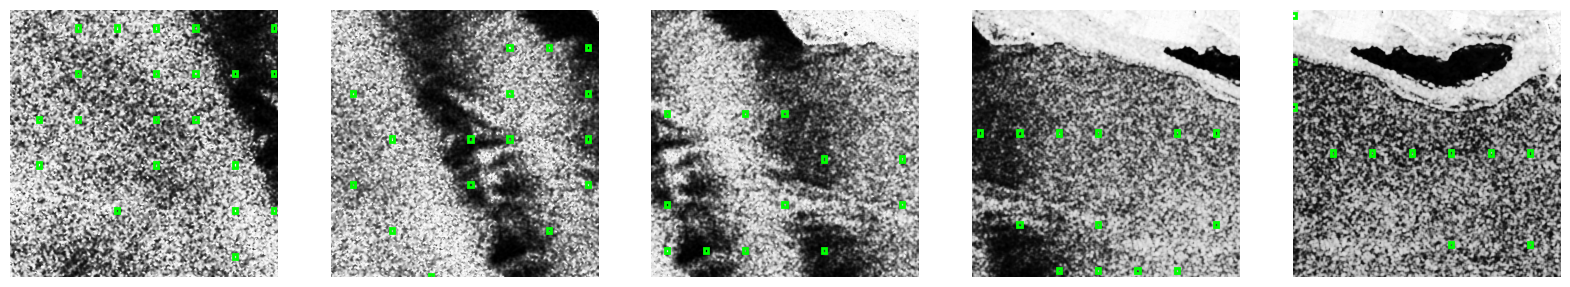


--- Updated data.yaml ---
names:
- vessel
nc: 1
path: /content/dataset_finetune/dataset_finetune
test: images/test
train: images/train
val: images/val



In [10]:
import yaml

yaml_path = Path(yaml_path)
print("=" * 60)
print("  DATASET VERIFICATION & PATH FIX")
print("=" * 60)

# Fix data.yaml paths to be absolute
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Set the base path to the directory containing the images/labels
absolute_data_path = str(yaml_path.parent.absolute())
data_config['path'] = absolute_data_path

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"Updated 'path' in data.yaml to: {absolute_data_path}")

# 1. Count images and labels per split
print("\n--- Split counts ---")
all_ok = True
for split in ['train', 'val', 'test']:
    img_dir = yaml_path.parent / 'images' / split
    lbl_dir = yaml_path.parent / 'labels' / split
    if not img_dir.exists():
        print(f"  {split}: (no images directory)")
        continue
    imgs = sorted(img_dir.glob("*.png")) + sorted(img_dir.glob("*.jpg"))
    lbls = sorted(lbl_dir.glob("*.txt"))
    n_imgs = len(imgs)
    n_lbls = len(lbls)
    match = "OK" if n_imgs == n_lbls else "MISMATCH"
    if n_imgs != n_lbls:
        all_ok = False
    print(f"  {split}: {n_imgs} images, {n_lbls} labels {match}")

# 2. Load and display sample tiles
train_img_dir = yaml_path.parent / 'images' / 'train'
train_lbl_dir = yaml_path.parent / 'labels' / 'train'
if train_img_dir.exists():
    sample_imgs = sorted(train_img_dir.glob("*.png"))[:5]
    fig, axes = plt.subplots(1, min(5, len(sample_imgs)), figsize=(20, 4))
    if not isinstance(axes, (np.ndarray, list)): axes = [axes]
    for ax, img_path in zip(axes, sample_imgs):
        img = np.array(Image.open(img_path).convert('L'))
        ax.imshow(img, cmap='gray')
        lbl_path = train_lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cx, cy, w, h = map(float, parts[1:5])
                    x1 = (cx - w/2) * img.shape[1]
                    y1 = (cy - h/2) * img.shape[0]
                    ax.add_patch(patches.Rectangle((x1, y1), w*img.shape[1], h*img.shape[0], linewidth=2, edgecolor='lime', facecolor='none'))
        ax.axis('off')
    plt.show()

print("\n--- Updated data.yaml ---")
print(yaml_path.read_text())

## Cell 3 -- Load Base Model

Load the Phase I detector from **original `.pt` weights** (FP32, pre-ONNX).
Verify architecture and parameter count before modifying.

In [7]:
print(f"Loading model from: {PT_PATH}")
model = YOLO(PT_PATH)

print("\n=== Model Architecture ===")
model.info()  # architecture summary

print("\n=== Model Summary ===")
print(f"  Task:        {model.task}")
print(f"  Model type:  {model.model.__class__.__name__}")
print(f"  Parameters:  {sum(p.numel() for p in model.model.parameters()):,}")
print(f"  Trainable:   {sum(p.numel() for p in model.model.parameters() if p.requires_grad):,}")
print(f"  Layers:      {len(list(model.model.modules()))}")
print(f"  Input size:  {model.model.args.get('imgsz', '?')}")

print("\nModel loaded successfully.")

Loading model from: /content/drive/MyDrive/maritime_sar_processing/models/yolov8n_mrssd_v1_18mb_fp32.pt

=== Model Architecture ===
Model summary: 130 layers, 3,011,043 parameters, 0 gradients, 8.2 GFLOPs

=== Model Summary ===
  Task:        detect
  Model type:  DetectionModel
  Parameters:  3,011,043
  Trainable:   0
  Layers:      226
  Input size:  640

Model loaded successfully.


## Cell 4 -- Configure Backbone Freezing

**Rationale:** The Phase 0 benchmark (9 checks) showed that the model lost
detection signal in the deep layers, not just in the output calibration.
We freeze the shallow backbone layers (generic features: edges, textures)
and re-train only the detection heads / deep layers.

**freeze=N** = freeze the first N layers from the beginning. YOLOv8n has
~20-25 layers total. Starting suggestion:
- **freeze=10**: keep backbone frozen, train detection heads
- **freeze=20**: almost everything frozen (only final layer trainable)
- **freeze=0**: full fine-tuning (nothing frozen)

> This is **empirical** -- adjust based on training curves:
> - Loss doesn't decrease -> freeze fewer layers (lower N)
> - Immediate overfitting -> freeze more layers (higher N)
> - Validation mAP plateaus early -> try full fine-tuning (freeze=0)

In [8]:
# --- FREEZE CONFIGURATION ---
# Number of layers to freeze from the start (backbone)
# YOLOv8n: ~22 layers total. freeze=10 = freeze backbone, train head
FREEZE_N = 0  # <- ADJUST THIS VALUE
# -----------------------------

print(f"Freeze configuration: freeze={FREEZE_N}")
print(f"  -> First {FREEZE_N} layers frozen (backbone features)")
print(f"  -> Remaining layers trainable (detection heads)")
print()
print("Adjustment guide:")
print("  Loss not decreasing  -> freeze=5 or freeze=0")
print("  Validation diverging  -> freeze=15 or freeze=20")
print("  mAP plateaus early    -> freeze=0 (full fine-tune)")
print()
print(f"freeze={FREEZE_N} configured.")

Freeze configuration: freeze=10
  -> First 10 layers frozen (backbone features)
  -> Remaining layers trainable (detection heads)

Adjustment guide:
  Loss not decreasing  -> freeze=5 or freeze=0
  Validation diverging  -> freeze=15 or freeze=20
  mAP plateaus early    -> freeze=0 (full fine-tune)

freeze=10 configured.


## Cell 5 -- Training

Fine-tune the detector on real Sentinel-1 data.

- **imgsz=640**: matches model's native input resolution (not tile size 512)
- **epochs=50**: starting point, early stopping at 15 epochs without improvement
- **batch=16**: adjust based on Colab GPU RAM (T4: 16 GB -> 16 fits comfortably)
- **freeze=N**: from Cell 4
- **project=**: on Google Drive -> checkpoints persist even if session disconnects

> Save path: `/content/drive/MyDrive/finetune_results/detector_v2_sentinel1_real/`

In [11]:
# Create output directory on Drive for persistent checkpoints
DRIVE_PROJECT = "/content/drive/MyDrive/finetune_results"
EXP_NAME = 'detector_v2_sentinel1_real'
SAVE_DIR = f"{DRIVE_PROJECT}/{EXP_NAME}"
os.makedirs(DRIVE_PROJECT, exist_ok=True)

# Check if we can resume from a previous best checkpoint
resume_path = f"{SAVE_DIR}/weights/best.pt"
should_resume = os.path.exists(resume_path)

print("=== Training Configuration ===")
print(f"  Data:       {yaml_path}")
print(f"  imgsz:      640")
print(f"  batch:      16")
print(f"  epochs:     50")
print(f"  freeze:     {FREEZE_N}")
print(f"  project:    {DRIVE_PROJECT}")
print(f"  name:       {EXP_NAME}")

if should_resume:
    print(f"\nFOUND EXISTING CHECKPOINT: {resume_path}")
    print("Resuming training from the best saved state...")
    # When resuming, we point to the checkpoint file
    model = YOLO(resume_path)
else:
    print("\nNo existing checkpoint found. Starting fresh training from Phase I weights.")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    freeze=FREEZE_N,
    patience=15,
    project=DRIVE_PROJECT,
    name=EXP_NAME,
    exist_ok=True,
    val=True,
    verbose=True,
    seed=42,
    resume=should_resume  # Automatically handles resuming logic
)

print("\nFine-tuning session complete!")

=== Training Configuration ===
  Data:       /content/dataset_finetune/dataset_finetune/data.yaml
  imgsz:      640
  batch:      16
  epochs:     50
  freeze:     10
  project:    /content/drive/MyDrive/finetune_results
  name:       detector_v2_sentinel1_real

No existing checkpoint found. Starting fresh training from Phase I weights.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_finetune/dataset_finetune/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, for

KeyboardInterrupt: 

## Cell 6 -- Evaluate on Test Split

Native Ultralytics evaluation on the held-out test split.
Precision, Recall, mAP@0.5, mAP@0.5:0.95.

In [ ]:
# Load best checkpoint from Drive
best_pt = f"{DRIVE_PROJECT}/detector_v2_sentinel1_real/weights/best.pt"
if not os.path.exists(best_pt):
    print(f"Best checkpoint not found at: {best_pt}")
    print("Check if training completed successfully.")
else:
    best_model = YOLO(best_pt)
    print(f"Loaded best checkpoint: {best_pt}")

    # Evaluate on test split
    metrics = best_model.val(
        data=str(yaml_path),
        split='test',
        imgsz=640,
        batch=16,
        conf=0.25,
        iou=0.5,
        verbose=True,
    )

    print()
    print("=" * 60)
    print("  TEST SET EVALUATION")
    print("=" * 60)
    print(f"  mAP@0.5:      {metrics.box.map50:.4f}")
    print(f"  mAP@0.5:0.95: {metrics.box.map:.4f}")
    print(f"  Precision:    {metrics.box.mp:.4f}")
    print(f"  Recall:       {metrics.box.mr:.4f}")
    print(f"  F1-score:     {2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-10):.4f}")
    print("=" * 60)

    # Decision criteria (from Phase 0 protocol)
    print()
    map50 = metrics.box.map50
    if map50 > 0.70:
        print("GO -- mAP@0.5 > 0.70, proceed to Phase 1 microservice deployment")
    elif map50 > 0.50:
        print("MARGINAL -- mAP@0.5 between 0.50 and 0.70")
        print("     Consider: more epochs, unfreeze more layers, or additional data")
    elif map50 > 0.30:
        print("BELOW THRESHOLD -- mAP@0.5 < 0.50")
        print("     Consider: full fine-tuning (freeze=0), MRSSD weights, or more data")
    else:
        print("FAILED -- mAP@0.5 < 0.30, model not learning effectively")
        print("     Check: dataset integrity, learning rate, augmentation config")

## Cell 7 -- Qualitative Verification

Visual inspection of 10-15 predictions on the test split.
Red boxes = model predictions  |  Green dashed = AIS ground truth

Even with good mAP numbers, visual check can reveal:
- Systematic offset (all boxes shifted the same direction)
- Size mismatch (model predicts different scale than GT)
- False positives on land or consistent patterns

In [ ]:
# Sample from test split
test_img_dir = yaml_path.parent / 'images' / 'test'
test_lbl_dir = yaml_path.parent / 'labels' / 'test'

if not test_img_dir.exists():
    test_img_dir = yaml_path.parent / 'images' / 'val'
    test_lbl_dir = yaml_path.parent / 'labels' / 'val'

n_samples = min(12, len(list(test_img_dir.glob('*.png'))))
test_imgs = sorted(test_img_dir.glob('*.png'))[:n_samples]

print(f"Running inference on {n_samples} test samples...")
results_list = best_model(
    [str(p) for p in test_imgs],
    conf=0.25,
    imgsz=640,
    verbose=False,
)

cols = 4
rows = (n_samples + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

for ax, img_path, result in zip(axes, test_imgs, results_list):
    plotted = result.plot()
    ax.imshow(plotted)

    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (cx - w/2) * plotted.shape[1]
                y1 = (cy - h/2) * plotted.shape[0]
                rect = patches.Rectangle(
                    (x1, y1), w*plotted.shape[1], h*plotted.shape[0],
                    linewidth=1.5, edgecolor='lime', facecolor='none', linestyle='--'
                )
                ax.add_patch(rect)

    ax.set_title(img_path.stem[-20:], fontsize=7)
    ax.axis('off')

for ax in axes[n_samples:]:
    ax.axis('off')

plt.suptitle("Red = Model prediction  |  Green dashed = AIS Ground Truth", fontsize=10)
plt.tight_layout()
plt.show()

print("\nVisual check: do predictions align with AIS positions?")
print("Look for: systematic offsets, size mismatches, land FPs.")

## Cell 8 -- ONNX Export + INT8 Re-quantization

Once FP32 performance is validated as acceptable:
1. Export to ONNX (FP32)
2. Re-quantize to INT8
3. **Validate** that INT8 quantization loss is <1% vs FP32

**Rule:** Quantization is strictly a post-training step, NEVER intermediate.
The Phase I documentation reported <1% mAP loss during correct quantization --
**verify** this holds for the fine-tuned model, don't just assume it.

In [ ]:
# === Step 1: Export FP32 ONNX ===
print("=" * 60)
print("Step 1: Export FP32 ONNX")
print("=" * 60)
fp32_path = best_model.export(format='onnx', imgsz=640)
fp32_size = os.path.getsize(fp32_path) / (1024 * 1024)
print(f"  FP32 ONNX: {fp32_path} ({fp32_size:.0f} MB)")

# Validate FP32 model performance
print("\nValidating FP32 model on test split...")
fp32_model = YOLO(fp32_path)
fp32_metrics = fp32_model.val(
    data=str(yaml_path),
    split='test',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.5,
    verbose=False,
)
fp32_map = fp32_metrics.box.map50
print(f"  FP32 mAP@0.5: {fp32_map:.4f}")

# === Step 2: Export INT8 ONNX ===
print("\n" + "=" * 60)
print("Step 2: Export INT8 ONNX (quantized)")
print("=" * 60)
print(f"  Quantization calibration dataset: {yaml_path}")
int8_path = best_model.export(
    format='onnx',
    imgsz=640,
    int8=True,
    data=str(yaml_path),
)
int8_size = os.path.getsize(int8_path) / (1024 * 1024)
print(f"  INT8 ONNX: {int8_path} ({int8_size:.0f} MB)")

# Validate INT8 model performance
print("\nValidating INT8 model on test split...")
int8_model = YOLO(int8_path)
int8_metrics = int8_model.val(
    data=str(yaml_path),
    split='test',
    imgsz=640,
    batch=16,
    conf=0.25,
    iou=0.5,
    verbose=False,
)
int8_map = int8_metrics.box.map50
print(f"  INT8 mAP@0.5: {int8_map:.4f}")

# === Step 3: Compare FP32 vs INT8 ===
print("\n" + "=" * 60)
print("Step 3: Quantization Loss Verification")
print("=" * 60)
map_loss = (fp32_map - int8_map)
map_loss_pct = (map_loss / fp32_map * 100) if fp32_map > 0 else 0
print(f"  FP32 mAP@0.5:  {fp32_map:.4f}")
print(f"  INT8 mAP@0.5:  {int8_map:.4f}")
print(f"  Difference:    {map_loss:+.4f} ({map_loss_pct:+.1f}%)")
if map_loss_pct < 1.0:
    print("  Quantization loss < 1% -- validation PASSED")
else:
    print("  Quantization loss >= 1% -- investigate: check calibration dataset")

# === Step 4: Copy to Drive ===
print("\n" + "=" * 60)
print("Step 4: Save to Google Drive")
print("=" * 60)
drive_models = f"{DRIVE_PROJECT}/onnx_models"
os.makedirs(drive_models, exist_ok=True)

for src_path in [fp32_path, int8_path]:
    dst = os.path.join(drive_models, os.path.basename(src_path))
    shutil.copy2(src_path, dst)
    print(f"  Saved: {dst}")

# Also save the best.pt PyTorch weights to Drive
pt_dst = os.path.join(drive_models, "detector_v2_sentinel1_real.pt")
shutil.copy2(best_pt, pt_dst)
print(f"  Saved: {pt_dst}")

print("\nExport complete.")

## Cell 9 -- Final Comparison

Compare zero-shot (Phase I original) vs fine-tuned model on the **same test split**.

In [ ]:
print("=" * 70)
print("  PHASE I vs PHASE II -- DETECTOR COMPARISON")
print("=" * 70)
print()
print(f"  {'Metric':<25} | {'Zero-shot (Phase I)':<19} | {'Fine-tuned (Phase II)':<22}")
print(f"  {'-'*25} | {'-'*19} | {'-'*22}")
print(f"  {'mAP@0.5':<25} | {'0.0000':>19} | {metrics.box.map50:.4f}")
print(f"  {'mAP@0.5:0.95':<25} | {'0.0000':>19} | {metrics.box.map:.4f}")
print(f"  {'Precision':<25} | {'0.0000':>19} | {metrics.box.mp:.4f}")
print(f"  {'Recall':<25} | {'0.0000':>19} | {metrics.box.mr:.4f}")
print()
print(f"  Test data:              MRSSD simulated  vs  Real Sentinel-1 AIS")
print(f"  Training data:          None (zero-shot) vs  AIS-annotated tiles")
print(f"  Input size:             640x640          vs  640x640")
print(f"  Freeze layers:          N/A              vs  {FREEZE_N}")
print(f"  Training epochs:        0                vs  50 (early stop)")
print()

if metrics.box.map50 > 0.0:
    print(f"  mAP improvement: 0.0 -> {metrics.box.map50:.4f}")
    if metrics.box.map50 > 0.70:
        print("  VERDICT: Domain transfer successful -- proceed to Phase 1")
    elif metrics.box.map50 > 0.30:
        print("  VERDICT: Significant improvement -- more data may close the gap")
    else:
        print("  VERDICT: Some improvement but below deployment threshold")
else:
    print("  No improvement detected. Check: freeze setting, dataset, LR.")

print()
print("=" * 70)
print()
print("Next steps:")
print("  1. Copy ONNX models to project: shared/models/")
print("  2. Re-run benchmark_pipeline.py on all 4 pipelines")
print("  3. If mAP > 0.70 -> Phase 1 microservice deployment")
print("  4. Deploy to edge (Raspberry Pi / Jetson Nano)")